In [2]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, shapiro, mannwhitneyu, pearsonr
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
display(df.head())
display((df.describe))

,Country,Region,HDI_Category,Population,Screening_Rate,Median_Age,Urbanization_Rate,Healthcare_Expenditure,GDP_Per_Capita,Obesity_Rate,...,Average_Diagnosis_Age,Survival_Rate,Access_To_Care,Education_Level,Women_Population,Breast_Cancer_Cases,Breast_Cancer_Deaths,Cases_Per_100K,Deaths_Per_100K,Mortality_Rate
0,United Kingdom,Asia,High,191540888,66.17,33,67.05,5873,13759,25.52,...,47,80.36,48.78,Primary,95111187,205111,38170,215.65,40.13,18.61
1,Nigeria,North America,High,129793398,63.18,30,65.86,604,35571,15.78,...,42,96.64,35.50,Primary,64449968,138989,25865,215.65,40.13,18.61
2,Saudi Arabia,Africa,Low,3532234,12.91,42,69.01,9138,37653,12.11,...,64,68.65,86.96,Secondary,1753959,3782,703,215.63,40.08,18.59
3,Australia,South America,Low,41960151,12.64,38,26.66,3767,1947,30.66,...,57,73.11,25.97,Tertiary,20835654,44933,8361,215.65,40.13,18.61
4,France,South America,Medium,96709040,44.87,42,41.22,4364,12059,21.48,...,66,50.85,76.07,Primary,48021661,103560,19272,215.65,40.13,18.61


<bound method NDFrame.describe of              Country         Region HDI_Category  Population  Screening_Rate  \
0     United Kingdom           Asia         High   191540888           66.17   
1            Nigeria  North America         High   129793398           63.18   
2       Saudi Arabia         Africa          Low     3532234           12.91   
3          Australia  South America          Low    41960151           12.64   
4             France  South America       Medium    96709040           44.87   
...              ...            ...          ...         ...             ...   
2995      Bangladesh  South America       Medium    38251557           76.39   
2996         Nigeria  South America         High   138021410           40.60   
2997          Brazil           Asia         High   149589002           67.70   
2998          Turkey        Oceania          Low   183065711           42.10   
2999          Turkey         Africa       Medium    52597754           61.59   

     

In [2]:
#checking missing values
print (df.isnull().sum())

Country                   0
Region                    0
HDI_Category              0
Population                0
Screening_Rate            0
Median_Age                0
Urbanization_Rate         0
Healthcare_Expenditure    0
GDP_Per_Capita            0
Obesity_Rate              0
Smoking_Rate              0
Alcohol_Consumption       0
Physical_Activity_Rate    0
Family_History_Rate       0
Breastfeeding_Rate        0
Average_Diagnosis_Age     0
Survival_Rate             0
Access_To_Care            0
Education_Level           0
Women_Population          0
Breast_Cancer_Cases       0
Breast_Cancer_Deaths      0
Cases_Per_100K            0
Deaths_Per_100K           0
Mortality_Rate            0
dtype: int64


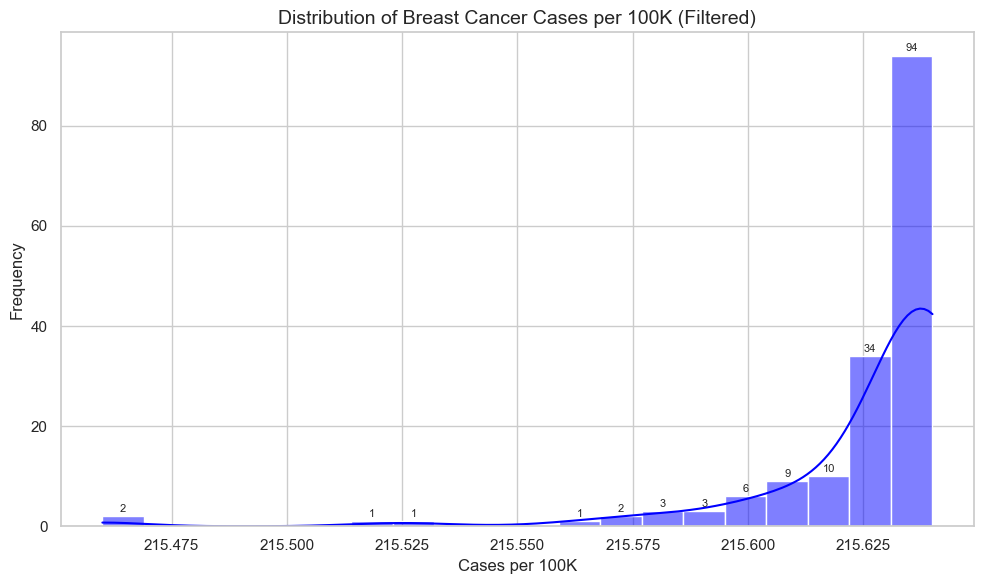

In [21]:
#graphs and analysis

#1.Histogram
sns.set(style="whitegrid")
filtered_df = df[df['Cases_Per_100K'] < df['Cases_Per_100K'].quantile(0.95)]

plt.figure(figsize=(10, 6))
hist_plot = sns.histplot(filtered_df['Cases_Per_100K'], bins=20, kde=True, color='blue')
for patch in hist_plot.patches:
    height = patch.get_height()
    if height > 0:
        plt.text(patch.get_x() + patch.get_width() / 2,
                 height + 0.5,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=8)
plt.title('Distribution of Breast Cancer Cases per 100K (Filtered)', fontsize=14)
plt.xlabel('Cases per 100K', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

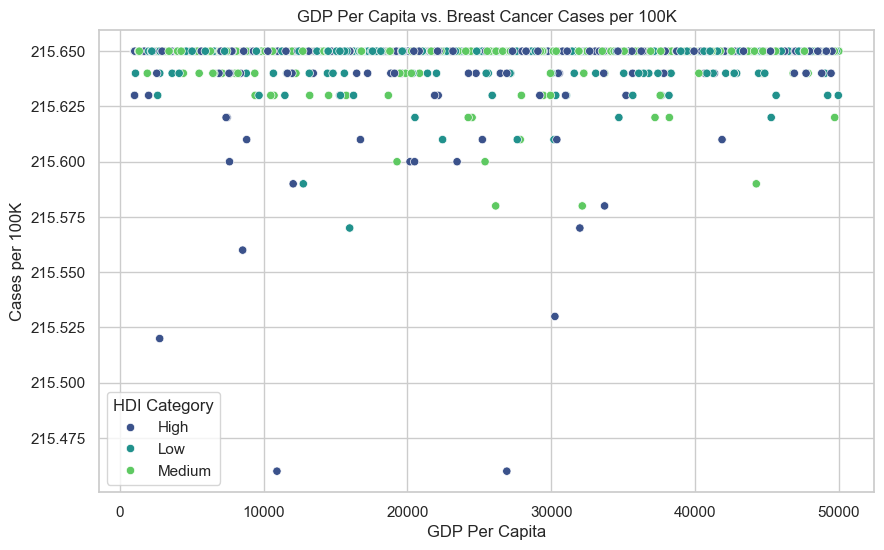

In [4]:
# 2.Scatter plot of GDP Per Capita vs. Breast Cancer Cases per 100K
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GDP_Per_Capita', y='Cases_Per_100K', data=df, hue='HDI_Category', palette='viridis')
plt.title('GDP Per Capita vs. Breast Cancer Cases per 100K')
plt.xlabel('GDP Per Capita')
plt.ylabel('Cases per 100K')
plt.legend(title='HDI Category')
plt.show()

C:\Users\HP-desktop\AppData\Local\Temp\ipykernel_460\3400398725.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Deaths_Per_100K', data=df, palette='Set2')


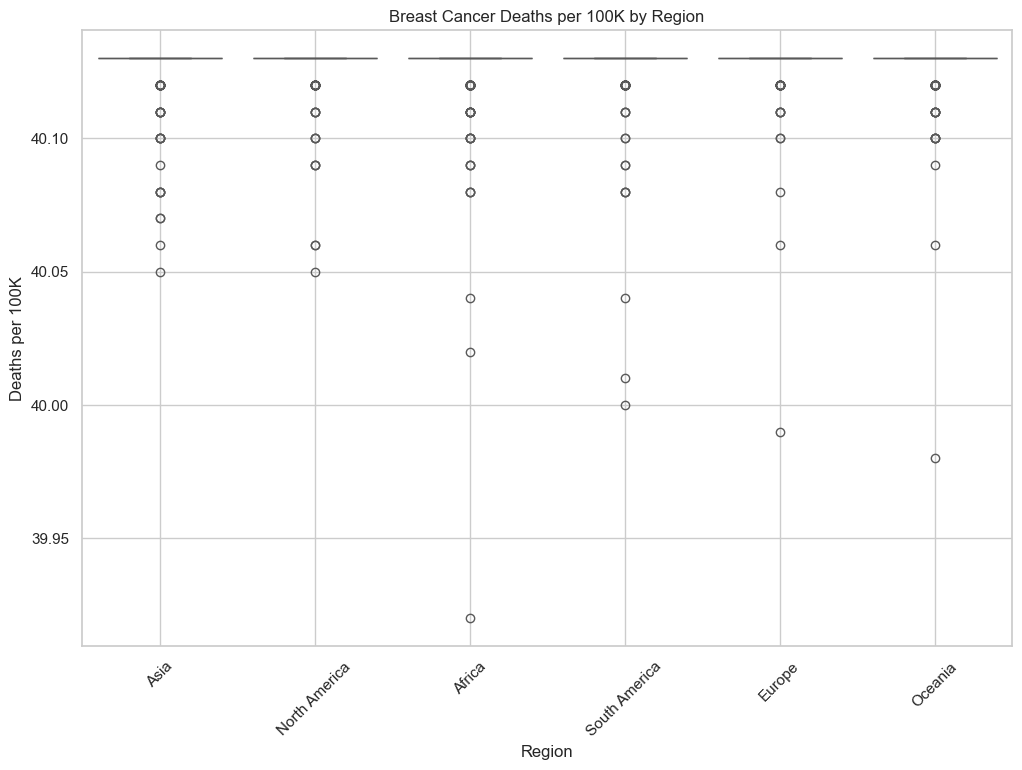

In [5]:
# 3. Box plot of Breast Cancer Cases per 100K by Region
plt.figure(figsize=(12, 8))
sns.boxplot(x='Region', y='Deaths_Per_100K', data=df, palette='Set2')
plt.title('Breast Cancer Deaths per 100K by Region')
plt.xlabel('Region')
plt.ylabel('Deaths per 100K')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


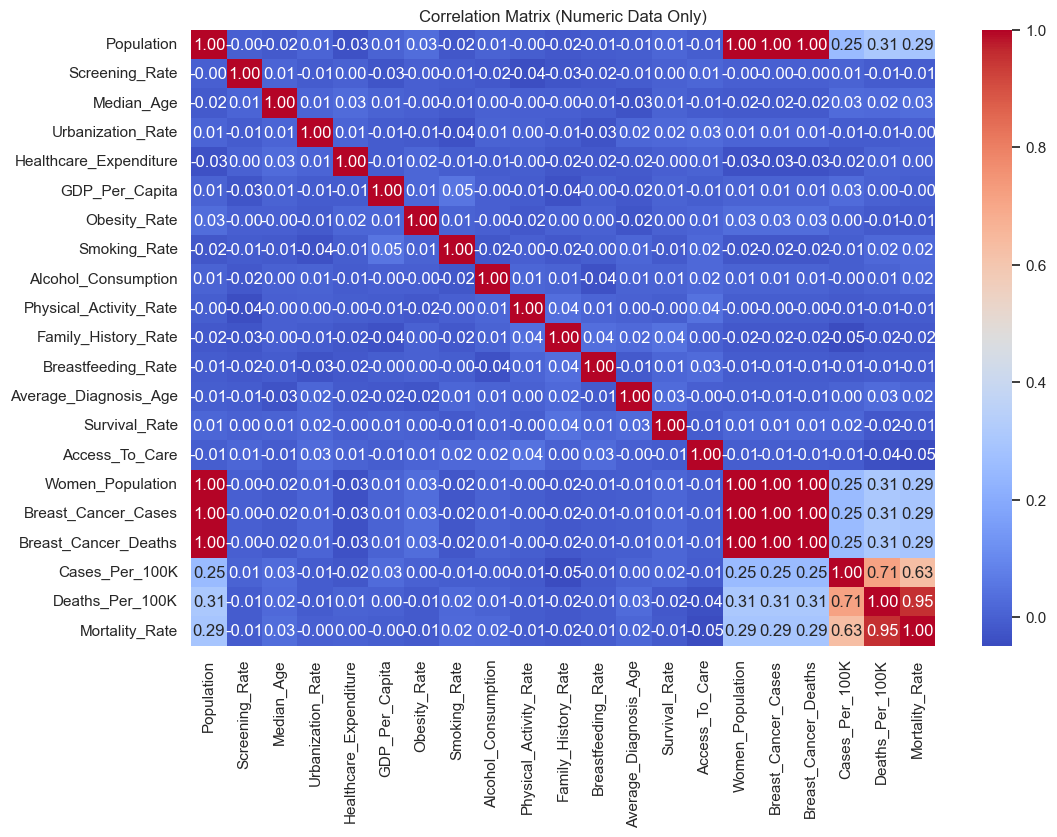

In [6]:
# 4. Heatmap of Correlation Matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
df_numeric = df.select_dtypes(include=['number'])
correlation_matrix = df_numeric.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Numeric Data Only)')
plt.show()


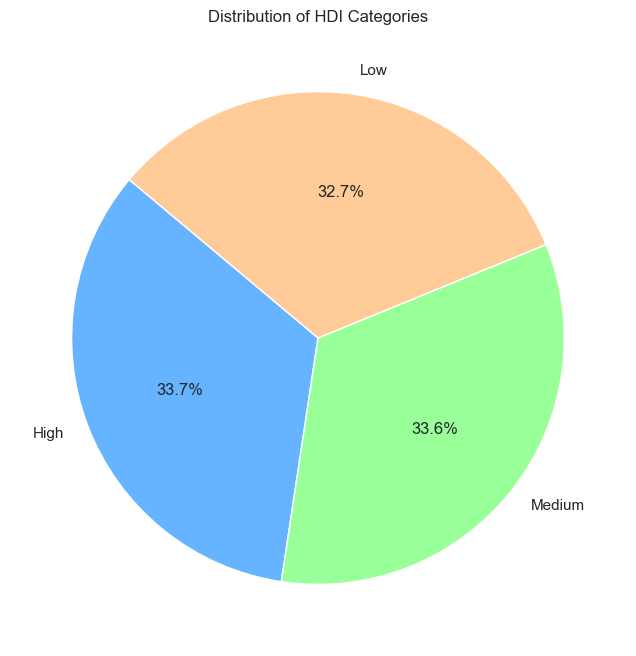

In [7]:
# 5. pie chart using HDI index
hdi_counts = df['HDI_Category'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(hdi_counts, labels=hdi_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff', '#99ff99', '#ffcc99'])
plt.title('Distribution of HDI Categories')
plt.show()

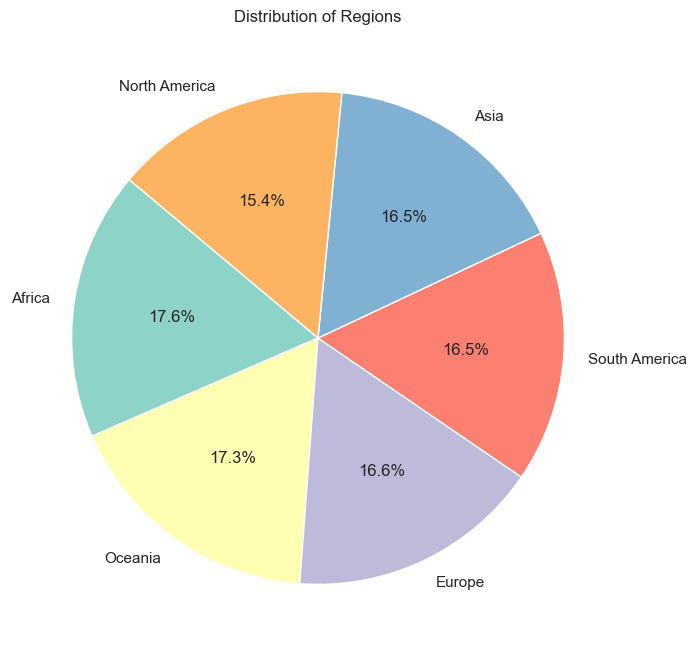

In [8]:
# 6. piechart for distributed region
region_counts = df['Region'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set3'))
plt.title('Distribution of Regions')
plt.show() 

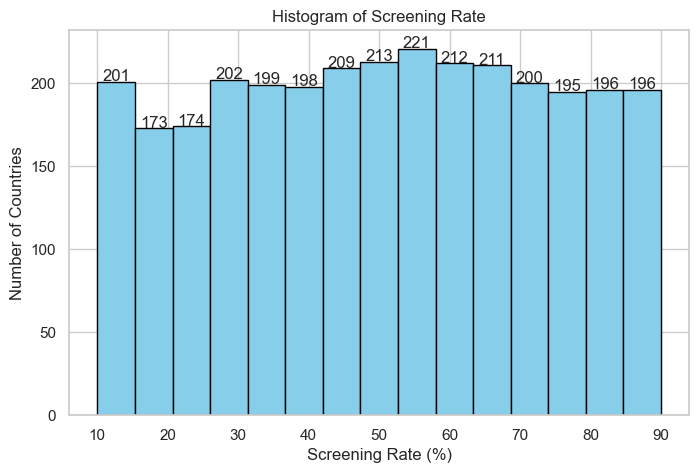

In [9]:
#***histogram using Different types of rows***
#1. histogram according to the screening rate
plt.figure(figsize=(8, 5))

counts, bins, patches = plt.hist(df['Screening_Rate'], bins=15, color='skyblue', edgecolor='black')

plt.title('Histogram of Screening Rate')
plt.xlabel('Screening Rate (%)')
plt.ylabel('Number of Countries')
plt.grid(True)

# Add counts on top of bars
bin_width = bins[1] - bins[0]  # calculate bin width only once
for count, bin_edge in zip(counts, bins[:-1]):
    plt.text(bin_edge + bin_width / 2, count + 0.5, str(int(count)), ha='center')

plt.show()


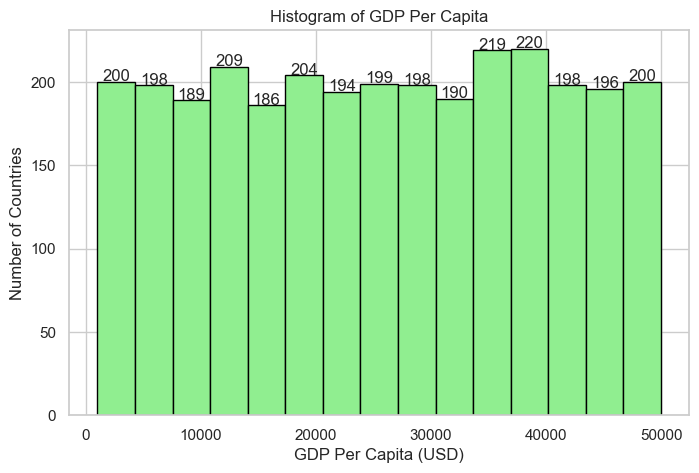

In [10]:
# 2. Histogram: GDP Per Capita
plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(df['GDP_Per_Capita'], bins=15, color='lightgreen', edgecolor='black')
plt.title('Histogram of GDP Per Capita')
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel('Number of Countries')
plt.grid(True)
bin_width = bins[1] - bins[0]
for count, bin_edge in zip(counts, bins[:-1]):
    plt.text(bin_edge + bin_width / 2, count + 0.5, str(int(count)), ha='center')
plt.show()

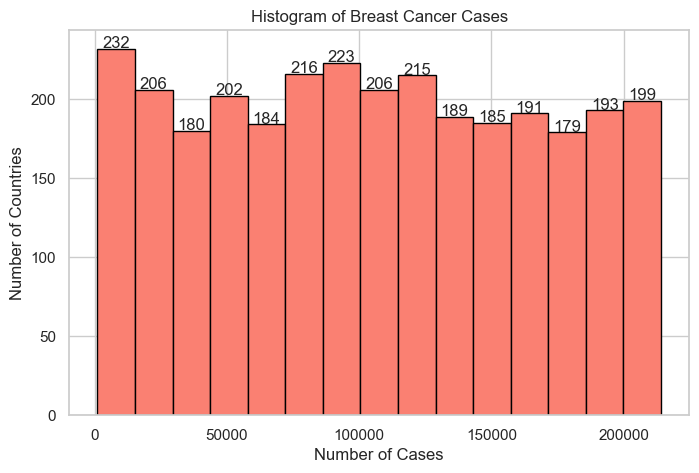

In [11]:
# 3. Histogram for Breast Cancer Cases
plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(df['Breast_Cancer_Cases'], bins=15, color='salmon', edgecolor='black')
plt.title('Histogram of Breast Cancer Cases')
plt.xlabel('Number of Cases')
plt.ylabel('Number of Countries')
plt.grid(True)
bin_width = bins[1] - bins[0]
for count, bin_edge in zip(counts, bins[:-1]):
    plt.text(bin_edge + bin_width / 2, count + 0.5, str(int(count)), ha='center')
plt.show()

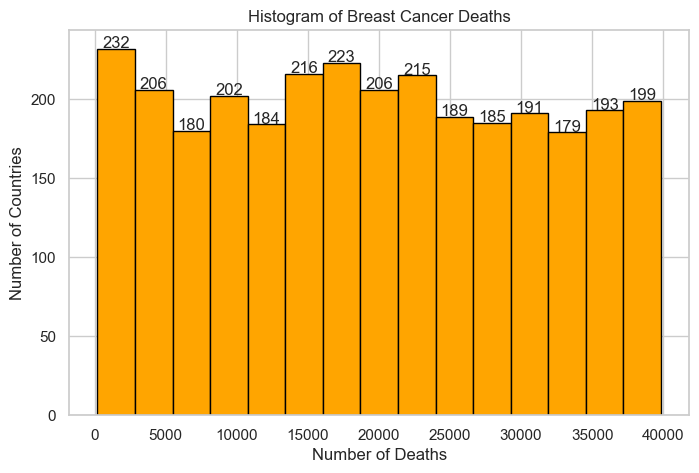

In [12]:
# 4. Histogram: Breast Cancer Deaths
plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(df['Breast_Cancer_Deaths'], bins=15, color='orange', edgecolor='black')
plt.title('Histogram of Breast Cancer Deaths')
plt.xlabel('Number of Deaths')
plt.ylabel('Number of Countries')
plt.grid(True)
bin_width = bins[1] - bins[0]
for count, bin_edge in zip(counts, bins[:-1]):
    plt.text(bin_edge + bin_width / 2, count + 0.5, str(int(count)), ha='center')
plt.show()

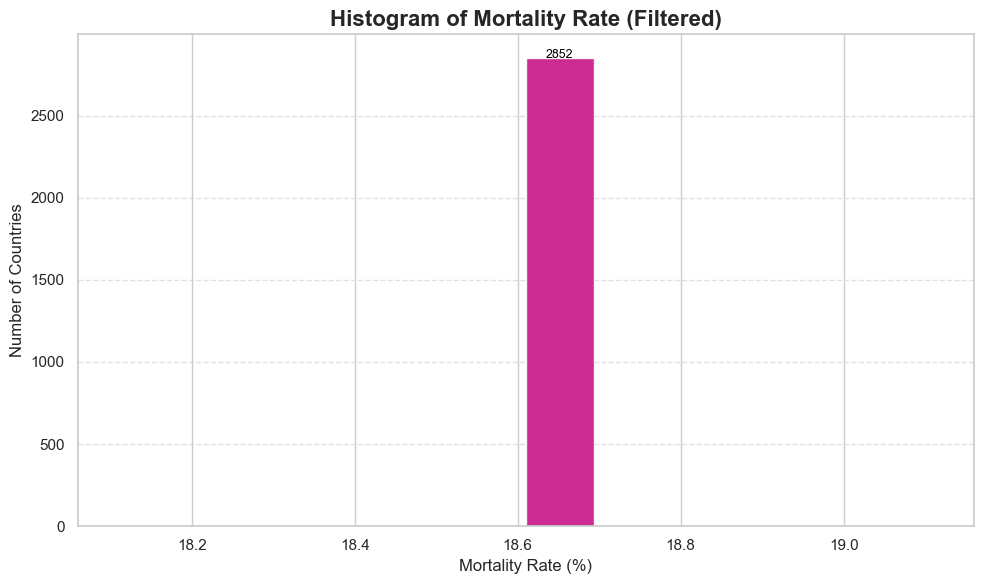

In [25]:
# 5.Histogram: Mortality Rate
Q1 = df['Mortality_Rate'].quantile(0.25)
Q3 = df['Mortality_Rate'].quantile(0.75)
IQR = Q3 - Q1
filtered_df = df[(df['Mortality_Rate'] >= Q1 - 1.5 * IQR) & (df['Mortality_Rate'] <= Q3 + 1.5 * IQR)]
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(filtered_df['Mortality_Rate'], bins=12, color='mediumvioletred', edgecolor='white', alpha=0.9)
plt.title('Histogram of Mortality Rate (Filtered)', fontsize=16, fontweight='bold')
plt.xlabel('Mortality Rate (%)', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

bin_width = bins[1] - bins[0]
for count, bin_edge in zip(counts, bins[:-1]):
    if count > 0:
        plt.text(bin_edge + bin_width / 2, count + 0.3,
                 str(int(count)),
                 ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

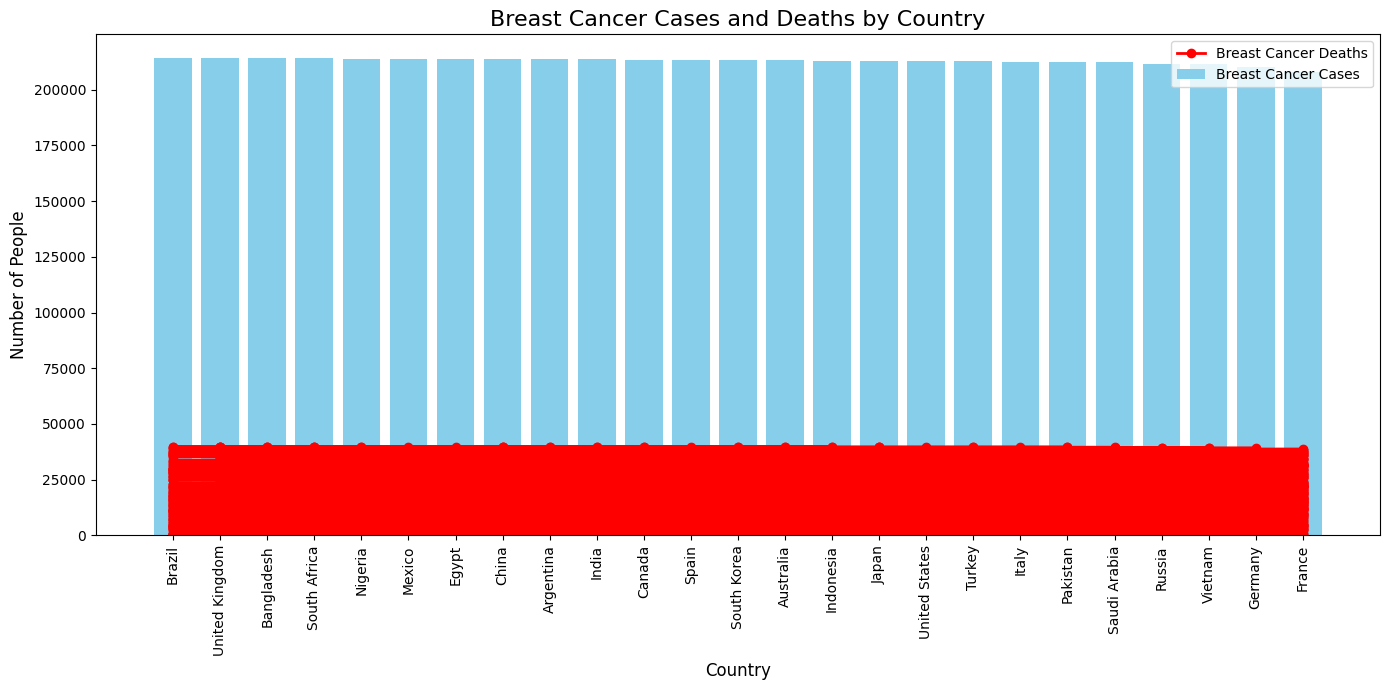

In [3]:
# Bar Chart: Breast Cancer Cases by Country
plt.figure(figsize=(12, 6))
sorted_df = df.sort_values(by='Breast_Cancer_Cases', ascending=False)
plt.figure(figsize=(14, 7))
plt.bar(sorted_df['Country'], sorted_df['Breast_Cancer_Cases'], color='skyblue', label='Breast Cancer Cases')
plt.plot(sorted_df['Country'], sorted_df['Breast_Cancer_Deaths'], color='red', marker='o', linewidth=2, label='Breast Cancer Deaths')
plt.xticks(rotation=90)
plt.title('Breast Cancer Cases and Deaths by Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

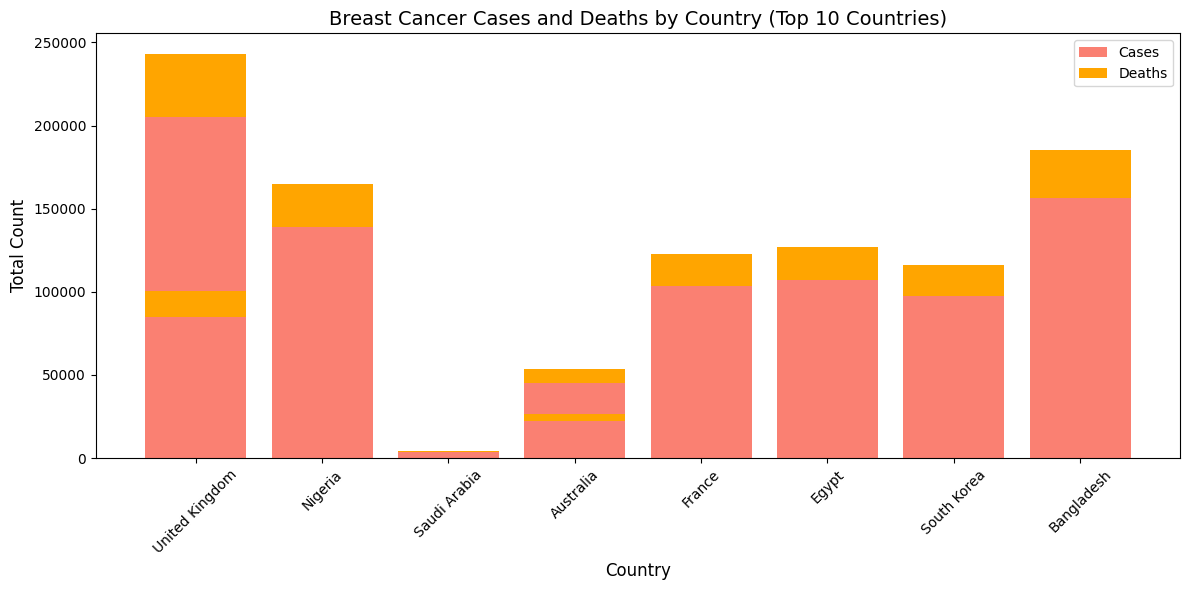

In [7]:
#Stacked Bar Chart of Cases and Deaths per Country
top_10 = df.head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10['Country'], top_10['Breast_Cancer_Cases'], label='Cases', color='salmon')
plt.bar(top_10['Country'], top_10['Breast_Cancer_Deaths'], bottom=top_10['Breast_Cancer_Cases'], label='Deaths', color='orange')
plt.xticks(rotation=45)
plt.title('Breast Cancer Cases and Deaths by Country (Top 10 Countries)', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

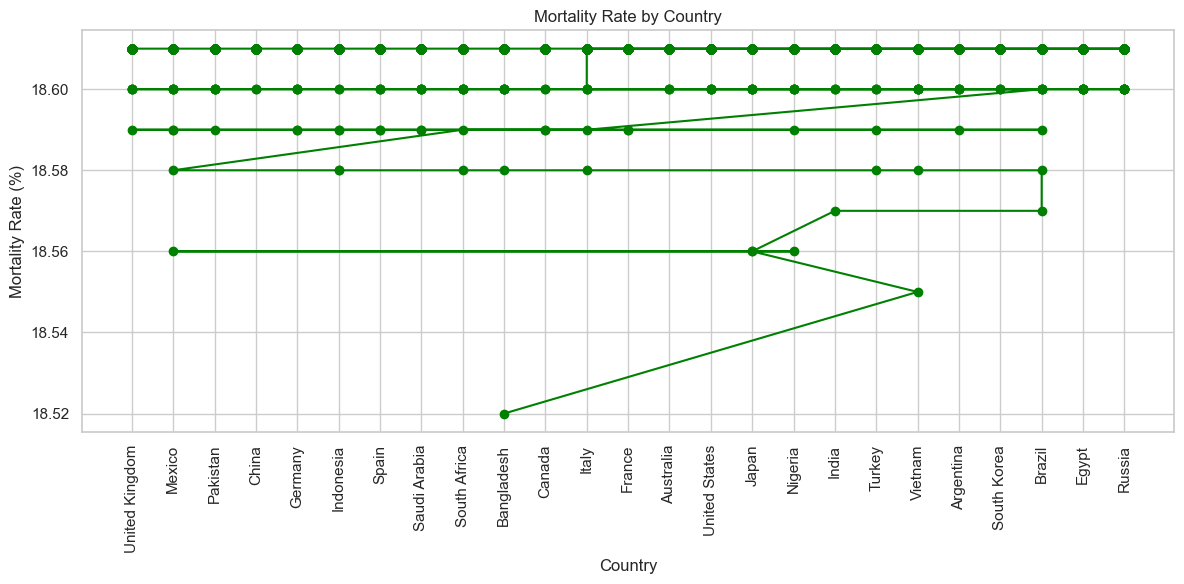

In [16]:
#Line Chart of Countries ranked by Mortality Rate
plt.figure(figsize=(12, 6))
df_sorted = df.sort_values(by='Mortality_Rate', ascending=False)
plt.plot(df_sorted['Country'], df_sorted['Mortality_Rate'], marker='o', linestyle='-', color='green')
plt.xticks(rotation=90)
plt.title('Mortality Rate by Country')
plt.xlabel('Country')
plt.ylabel('Mortality Rate (%)')
plt.tight_layout()
plt.show()

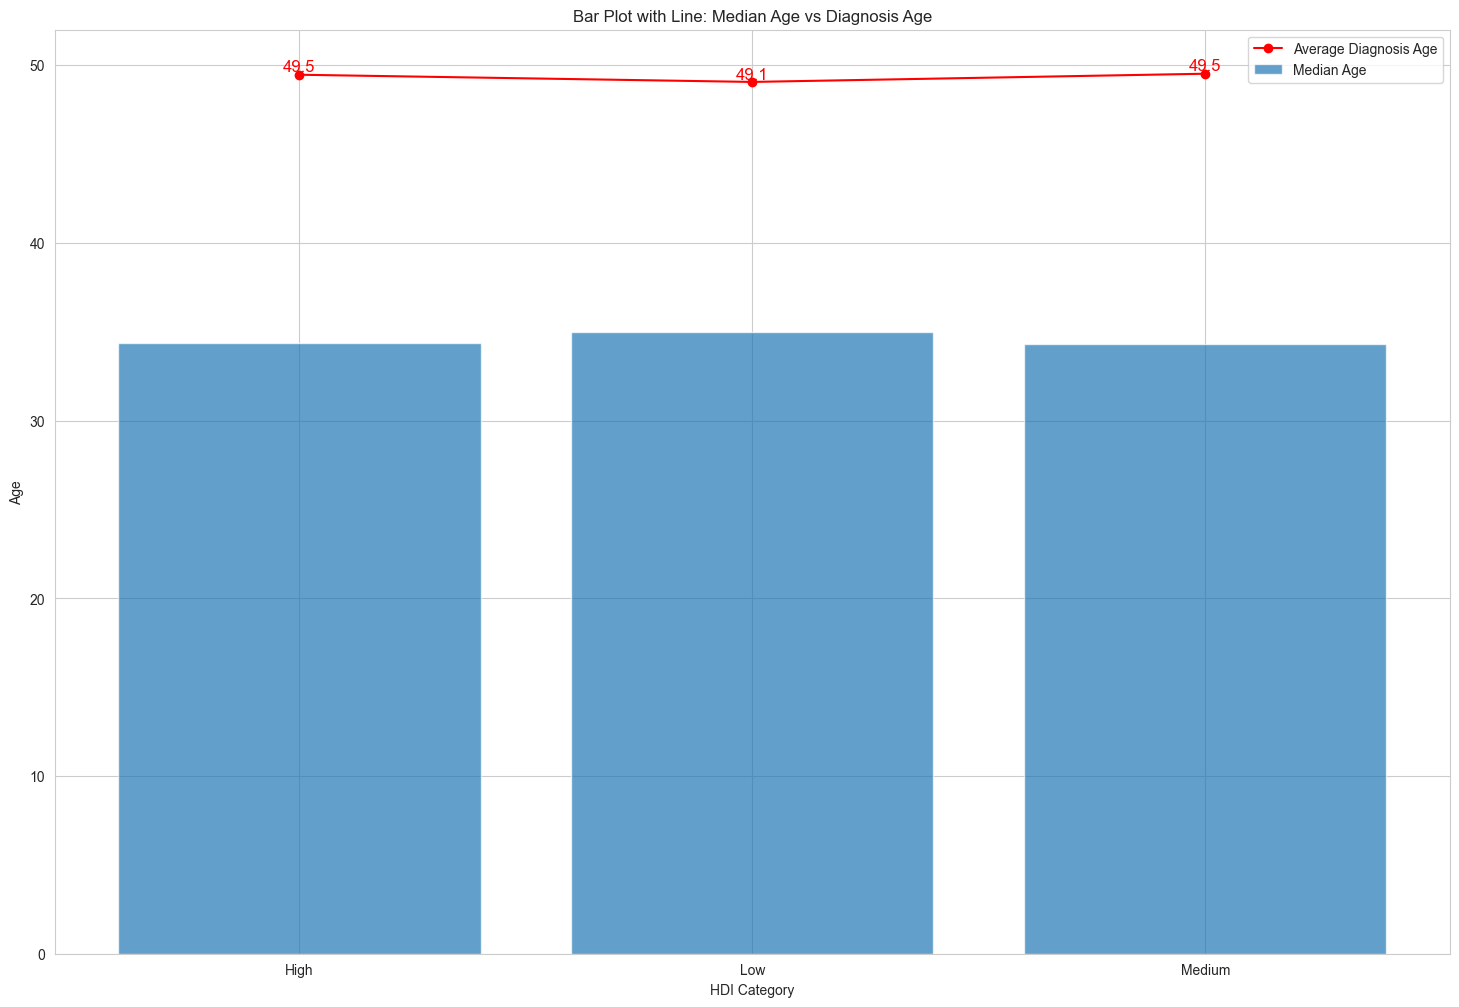

In [ ]:
# Bar Plot with Line - Median Age vs Average Diagnosis Age
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(18, 12))

median_age = df.groupby("HDI_Category")["Median_Age"].mean()
diagnosis_age = df.groupby("HDI_Category")["Average_Diagnosis_Age"].mean()
ax1.bar(median_age.index, median_age, label="Median Age", alpha=0.7)
ax1.plot(median_age.index, diagnosis_age, marker="o", linestyle="-", color="red", label="Average Diagnosis Age")

# Add numbers on Average Diagnosis Age
for i, txt in enumerate(diagnosis_age):
    ax1.text(i, txt, f'{txt:.1f}', ha='center', va='bottom', fontsize=12, color='red')

ax1.set_title("Bar Plot with Line: Median Age vs Diagnosis Age")
ax1.set_xlabel("HDI Category")
ax1.set_ylabel("Age")
ax1.legend(loc="best")
plt.show()



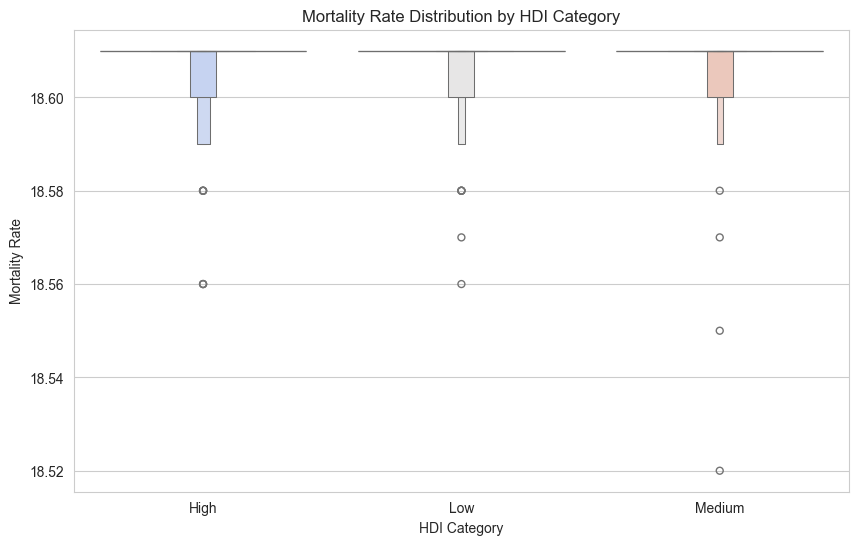

In [ ]:
# Boxen plot using Mortality Rate Distribution by HDI Category
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxenplot(x=df["HDI_Category"], y=df["Mortality_Rate"], hue=df["HDI_Category"], legend=False, ax=ax, palette="coolwarm")
ax.set_title("Mortality Rate Distribution by HDI Category")
ax.set_xlabel("HDI Category")
ax.set_ylabel("Mortality Rate")
plt.show()


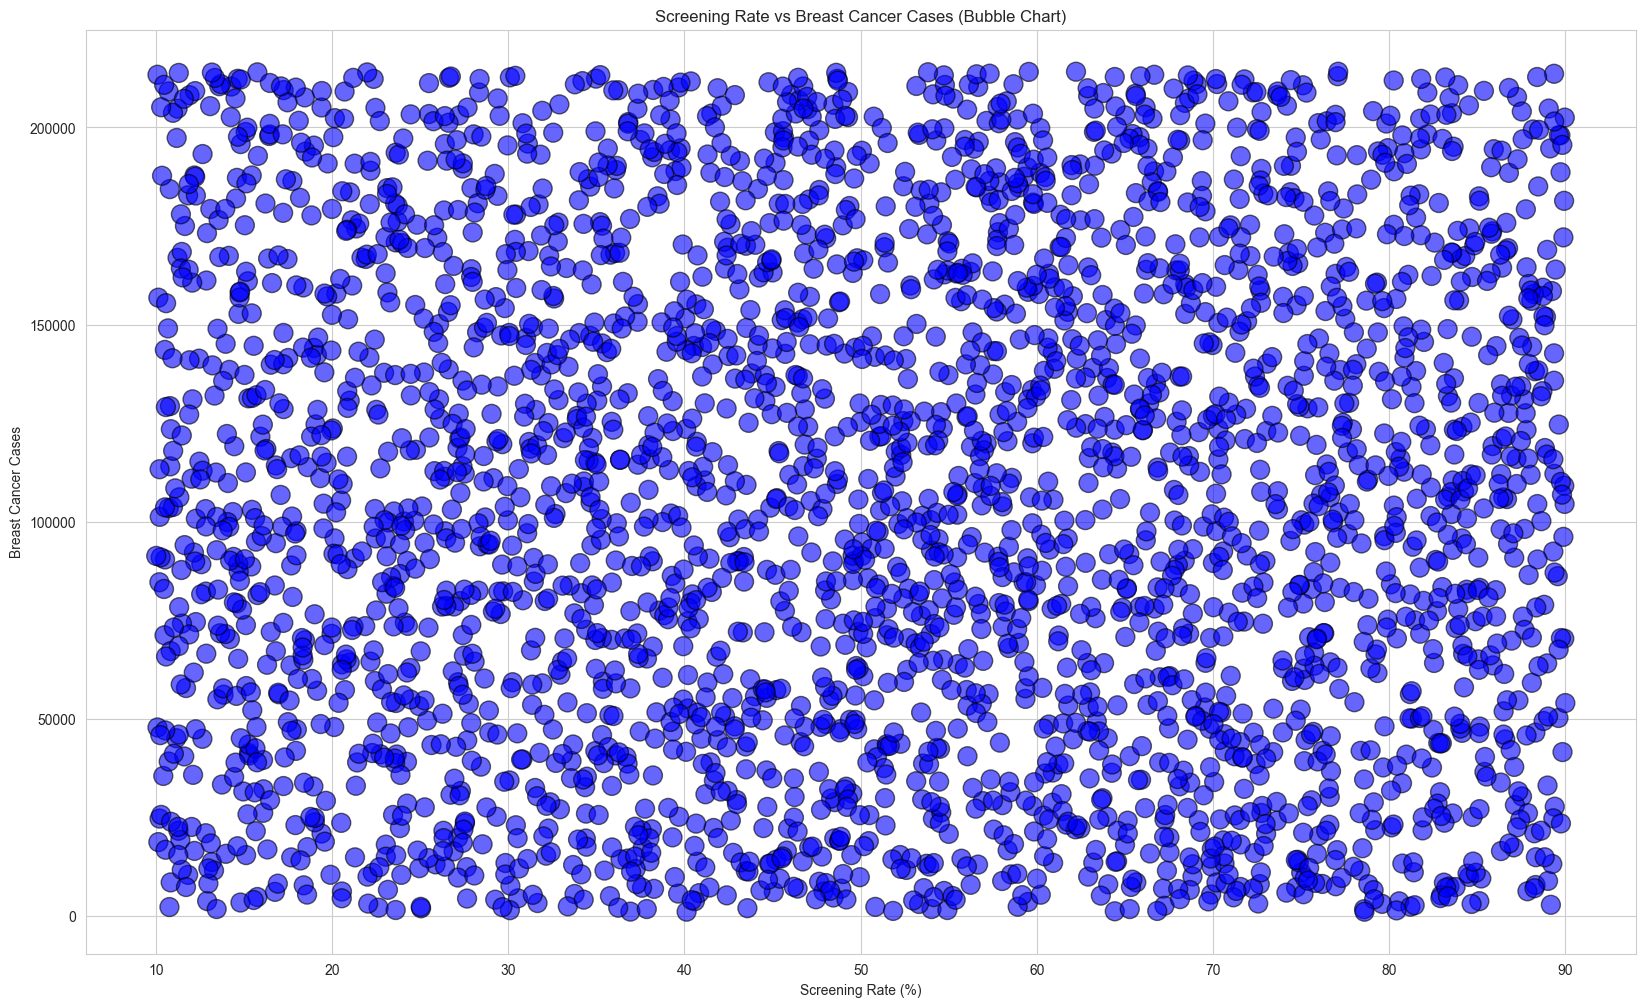

In [ ]:
# Bubble chart using screening rate vs Breast Cancer Cases
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
df = df.dropna(subset=["Screening_Rate", "Breast_Cancer_Cases", "Mortality_Rate"])
fig, ax = plt.subplots(figsize=(20, 12))

bubble_size = df["Mortality_Rate"] * 10
scatter = ax.scatter(df["Screening_Rate"], df["Breast_Cancer_Cases"], 
                      s=bubble_size, alpha=0.6, color="blue", edgecolors="k")
ax.set_title("Screening Rate vs Breast Cancer Cases (Bubble Chart)")
ax.set_xlabel("Screening Rate (%)")
ax.set_ylabel("Breast Cancer Cases")
plt.show()

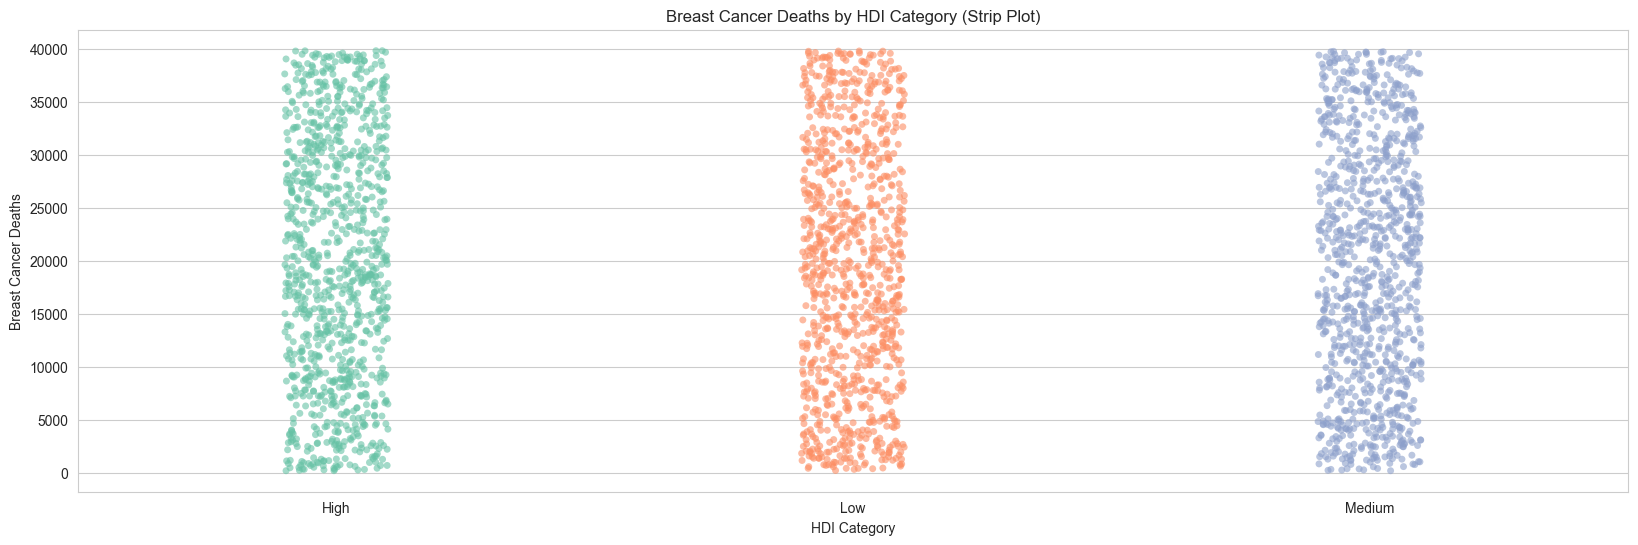

In [ ]:
# Strip plot using HDI Category and Breast Cancer Deaths
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
fig, ax = plt.subplots(figsize=(20, 6))
sns.stripplot(x=df["HDI_Category"], y=df["Breast_Cancer_Deaths"], hue=df["HDI_Category"], 
              alpha=0.6, jitter=True, ax=ax, palette="Set2", legend=False)
ax.set_title("Breast Cancer Deaths by HDI Category (Strip Plot)")
ax.set_xlabel("HDI Category")
ax.set_ylabel("Breast Cancer Deaths")
plt.show()


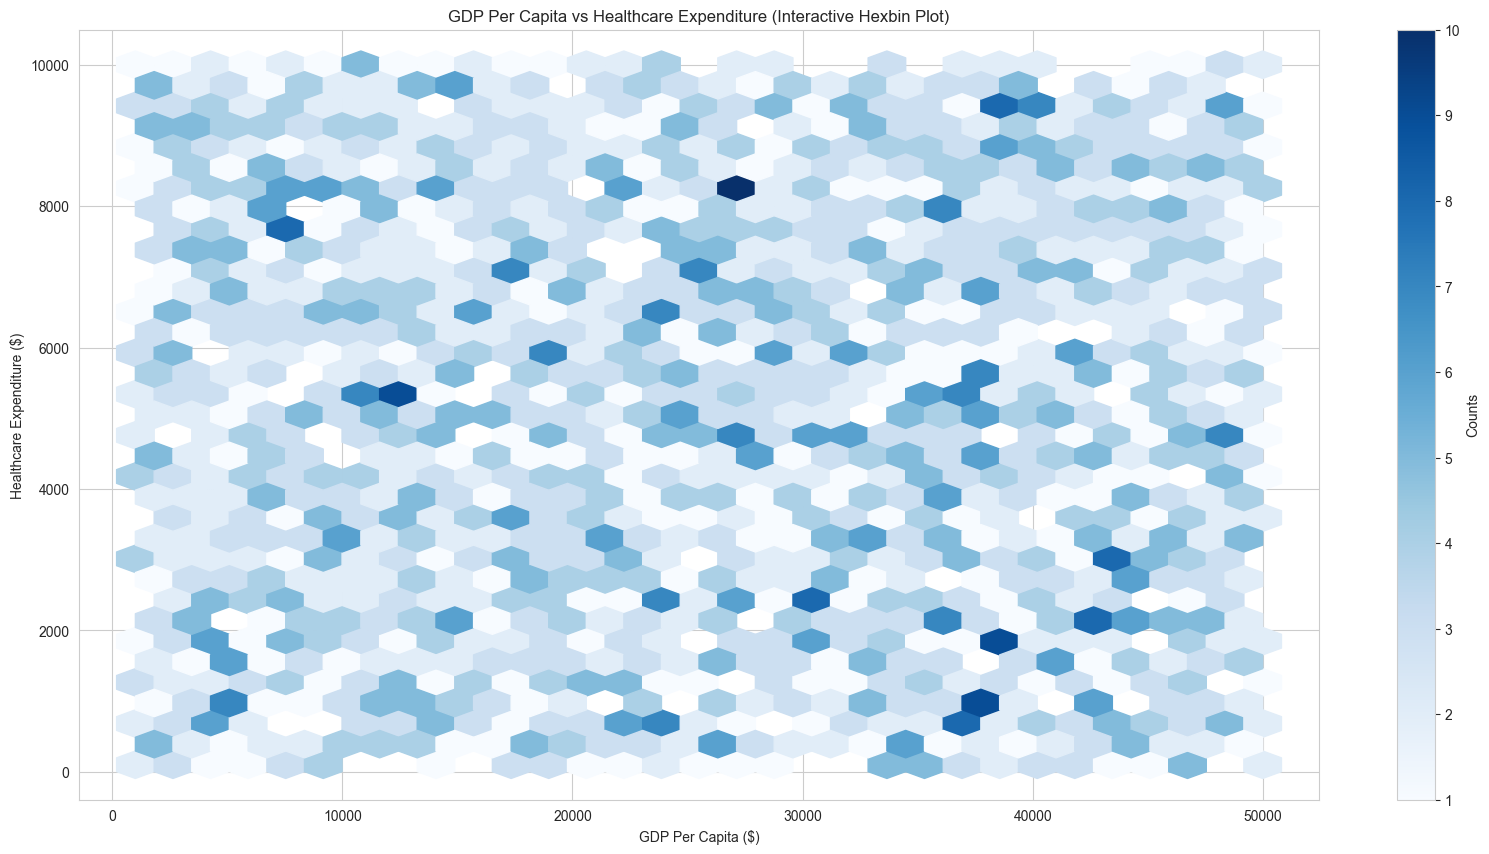

In [ ]:
# Hexbin plot GDP vs Health Care Expenditure
import pandas as pd
import matplotlib.pyplot as plt
import mplcursors

df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
df = df.dropna(subset=["GDP_Per_Capita", "Healthcare_Expenditure"])
fig, ax = plt.subplots(figsize=(20, 10))

hb = ax.hexbin(df["GDP_Per_Capita"], df["Healthcare_Expenditure"], gridsize=30, cmap="Blues", mincnt=1)
cb = plt.colorbar(hb, ax=ax)
cb.set_label("Counts")
ax.set_title("GDP Per Capita vs Healthcare Expenditure (Interactive Hexbin Plot)")
ax.set_xlabel("GDP Per Capita ($)")
ax.set_ylabel("Healthcare Expenditure ($)")
# Make hexbin interactive(i tried but not working)
cursor = mplcursors.cursor(hb, hover=True)
cursor.connect("add", lambda sel: sel.annotation.set_text(f"Count: {sel.target[0]}"))
plt.show()


In [ ]:
#Sunburst chart using Breast Cancer Cases by Region and HDI Category
import pandas as pd
import plotly.express as px
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
grouped_df = df.groupby(["Region", "HDI_Category"])["Breast_Cancer_Cases"].sum().reset_index()
fig = px.sunburst(grouped_df, path=["Region", "HDI_Category"], values="Breast_Cancer_Cases", 
                  title="Breast Cancer Cases by Region and HDI Category", color="Breast_Cancer_Cases",
                  color_continuous_scale="RdBu")
fig.show()


In [17]:
title = "Problem Statements"
line = "=" * 162
print(line)
print(title.center(155))
print(line)


                                                                     Problem Statements                                                                    


In [18]:
print("Problem 1: What are the data types of each column?")
display("Data types:", df.dtypes)


Problem 1: What are the data types of each column?


'Data types:'

Country                    object
Region                     object
HDI_Category               object
Population                  int64
Screening_Rate            float64
Median_Age                  int64
Urbanization_Rate         float64
Healthcare_Expenditure      int64
GDP_Per_Capita              int64
Obesity_Rate              float64
Smoking_Rate              float64
Alcohol_Consumption       float64
Physical_Activity_Rate    float64
Family_History_Rate       float64
Breastfeeding_Rate        float64
Average_Diagnosis_Age       int64
Survival_Rate             float64
Access_To_Care            float64
Education_Level            object
Women_Population            int64
Breast_Cancer_Cases         int64
Breast_Cancer_Deaths        int64
Cases_Per_100K            float64
Deaths_Per_100K           float64
Mortality_Rate            float64
dtype: object

In [8]:
print("Problem 2: What is the summary statistics of numerical columns?")
pd.options.display.float_format = '{:.3f}'.format
summary = df.describe().round(3).to_string()
print("Summary statistics:\n", summary)

Problem 2: What is the summary statistics of numerical columns?
Summary statistics:
          Population  Screening_Rate  Median_Age  Urbanization_Rate  Healthcare_Expenditure  GDP_Per_Capita  Obesity_Rate  Smoking_Rate  Alcohol_Consumption  Physical_Activity_Rate  Family_History_Rate  Breastfeeding_Rate  Average_Diagnosis_Age  Survival_Rate  Access_To_Care  Women_Population  Breast_Cancer_Cases  Breast_Cancer_Deaths  Cases_Per_100K  Deaths_Per_100K  Mortality_Rate
count      3000.000        3000.000    3000.000           3000.000                3000.000        3000.000      3000.000      3000.000             3000.000                3000.000             3000.000            3000.000               3000.000       3000.000        3000.000          3000.000             3000.000              3000.000        3000.000         3000.000        3000.000
mean   98825388.199          50.479      34.558             54.566                5059.401       25668.863        27.572        22.173           

In [20]:
print("Problem 3: How many unique countries are in the dataset?")
print("Number of unique countries:", df['Country'].nunique())

Problem 3: How many unique countries are in the dataset?
Number of unique countries: 25


In [21]:
print('Problem 4: What are the unique HDI categories?')
print("Unique HDI categories:", df['HDI_Category'].unique())

Problem 4: What are the unique HDI categories?
Unique HDI categories: ['High' 'Low' 'Medium']


In [22]:
print('Problem 5: What is the average GDP per capita?')
print("Average GDP per capita:", df['GDP_Per_Capita'].mean())

Problem 5: What is the average GDP per capita?
Average GDP per capita: 25668.862666666668


In [23]:
print('Problem 6: What is the maximum number of breast cancer cases per 100K?')
print("Maximum cases per 100K:", df['Cases_Per_100K'].max())

Problem 6: What is the maximum number of breast cancer cases per 100K?
Maximum cases per 100K: 215.65


In [24]:
print('Problem 7: Drop rows with missing values.')
df_cleaned = df.dropna()
print("Shape after dropping missing values:", df_cleaned.shape)


Problem 7: Drop rows with missing values.
Shape after dropping missing values: (3000, 25)


In [25]:
print('Problem 8: Remove duplicate rows.')
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Problem 8: Remove duplicate rows.
Shape after removing duplicates: (3000, 25)


In [6]:
import pandas as pd
from IPython.display import display
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
print('Problem 9: Filter rows where `Cases_Per_100K` is greater than 200.')
filtered_df = df[df['Cases_Per_100K'] > 200]
display("Filtered rows:\n", filtered_df)

Problem 9: Filter rows where `Cases_Per_100K` is greater than 200.


'Filtered rows:\n'

,Country,Region,HDI_Category,Population,Screening_Rate,Median_Age,Urbanization_Rate,Healthcare_Expenditure,GDP_Per_Capita,Obesity_Rate,...,Average_Diagnosis_Age,Survival_Rate,Access_To_Care,Education_Level,Women_Population,Breast_Cancer_Cases,Breast_Cancer_Deaths,Cases_Per_100K,Deaths_Per_100K,Mortality_Rate
0,United Kingdom,Asia,High,191540888,66.17,33,67.05,5873,13759,25.52,...,47,80.36,48.78,Primary,95111187,205111,38170,215.65,40.13,18.61
1,Nigeria,North America,High,129793398,63.18,30,65.86,604,35571,15.78,...,42,96.64,35.50,Primary,64449968,138989,25865,215.65,40.13,18.61
2,Saudi Arabia,Africa,Low,3532234,12.91,42,69.01,9138,37653,12.11,...,64,68.65,86.96,Secondary,1753959,3782,703,215.63,40.08,18.59
3,Australia,South America,Low,41960151,12.64,38,26.66,3767,1947,30.66,...,57,73.11,25.97,Tertiary,20835654,44933,8361,215.65,40.13,18.61
4,France,South America,Medium,96709040,44.87,42,41.22,4364,12059,21.48,...,66,50.85,76.07,Primary,48021661,103560,19272,215.65,40.13,18.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Bangladesh,South America,Medium,38251557,76.39,33,81.72,2231,42536,31.40,...,42,95.13,29.69,Secondary,18994122,40961,7622,215.65,40.13,18.61
2996,Nigeria,South America,High,138021410,40.60,40,82.27,5364,20447,28.08,...,41,95.87,54.08,Secondary,68535654,147800,27504,215.65,40.13,18.61
2997,Brazil,Asia,High,149589002,67.70,23,56.40,5350,31109,41.68,...,44,82.79,66.50,Secondary,74279636,160187,29810,215.65,40.13,18.61
2998,Turkey,Oceania,Low,183065711,42.10,39,55.16,5025,16752,26.59,...,37,66.74,61.31,Primary,90902769,196035,36481,215.65,40.13,18.61


In [27]:
print('Problem 10: Create a new column `Total_Cases` as `Population * Cases_Per_100K / 100000`.')
df['Total_Cases'] = df['Population'] * df['Cases_Per_100K'] / 100000
print("Total_Cases column added:\n", df[['Country', 'Total_Cases']].head())


Problem 10: Create a new column `Total_Cases` as `Population * Cases_Per_100K / 100000`.
Total_Cases column added:
           Country  Total_Cases
0  United Kingdom   413057.925
1         Nigeria   279899.463
2    Saudi Arabia     7616.556
3       Australia    90487.066
4          France   208553.045


In [28]:
print('Problem 11: Drop the column `Total_Cases`.')
df.drop(columns=['Total_Cases'], inplace=True)
print("Column names after dropping Total_Cases:", df.columns.tolist())


Problem 11: Drop the column `Total_Cases`.
Column names after dropping Total_Cases: ['Country', 'Region', 'HDI_Category', 'Population', 'Screening_Rate', 'Median_Age', 'Urbanization_Rate', 'Healthcare_Expenditure', 'GDP_Per_Capita', 'Obesity_Rate', 'Smoking_Rate', 'Alcohol_Consumption', 'Physical_Activity_Rate', 'Family_History_Rate', 'Breastfeeding_Rate', 'Average_Diagnosis_Age', 'Survival_Rate', 'Access_To_Care', 'Education_Level', 'Women_Population', 'Breast_Cancer_Cases', 'Breast_Cancer_Deaths', 'Cases_Per_100K', 'Deaths_Per_100K', 'Mortality_Rate']


In [29]:
print('Problem 12: What is the correlation between `GDP_Per_Capita` and `Cases_Per_100K`?')
print("Correlation between GDP_Per_Capita and Cases_Per_100K:", df['GDP_Per_Capita'].corr(df['Cases_Per_100K']))


Problem 12: What is the correlation between `GDP_Per_Capita` and `Cases_Per_100K`?
Correlation between GDP_Per_Capita and Cases_Per_100K: 0.025960486126742115


In [ ]:
print('Problem 13: What is the average `Obesity_Rate` for each `HDI_Category`?')
print("Average Obesity Rate by HDI Category:\n", df.groupby('HDI_Category')['Obesity_Rate'].mean())


Problem 13: What is the average `Obesity_Rate` for each `HDI_Category`?
Average Obesity Rate by HDI Category:
 HDI_Category
High     27.733
Low      27.982
Medium   27.011
Name: Obesity_Rate, dtype: float64


In [31]:
print('Problem 14: What is the median `Healthcare_Expenditure`?')
print("Median Healthcare Expenditure:", df['Healthcare_Expenditure'].median())


Problem 14: What is the median `Healthcare_Expenditure`?
Median Healthcare Expenditure: 5082.0


In [32]:
print('Problem 15: What is the standard deviation of `Smoking_Rate`?')
print("Standard Deviation of Smoking Rate:", df['Smoking_Rate'].std())


Problem 15: What is the standard deviation of `Smoking_Rate`?
Standard Deviation of Smoking Rate: 10.285318871247988


In [33]:
print('Problem 16: What is the skewness of `Cases_Per_100K`?')
print("Skewness of Cases_Per_100K:", df['Cases_Per_100K'].skew())


Problem 16: What is the skewness of `Cases_Per_100K`?
Skewness of Cases_Per_100K: -12.997602748559444


In [34]:
print('Problem 17: What is the kurtosis of `Deaths_Per_100K`?')
print("Kurtosis of Deaths_Per_100K:", df['Deaths_Per_100K'].kurtosis())


Problem 17: What is the kurtosis of `Deaths_Per_100K`?
Kurtosis of Deaths_Per_100K: 150.20300538127225


In [35]:
print('Problem 18: Perform a t-test to compare `Cases_Per_100K` between High and Low HDI categories.')

high_hdi = df[df['HDI_Category'] == 'High']['Cases_Per_100K']
low_hdi = df[df['HDI_Category'] == 'Low']['Cases_Per_100K']
t_stat, p_value = ttest_ind(high_hdi, low_hdi, nan_policy='omit')

print("T-test statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 3))

Problem 18: Perform a t-test to compare `Cases_Per_100K` between High and Low HDI categories.
T-test statistic: -1.901
P-value: 0.057


In [6]:
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency, shapiro, mannwhitneyu, pearsonr
from IPython.display import display
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")

print('Problem 19: Perform a chi-square test between `HDI_Category` and `Region`.')
contingency_table = pd.crosstab(df['HDI_Category'], df['Region'])
display("Chi-square test result:", chi2_contingency(contingency_table))


Problem 19: Perform a chi-square test between `HDI_Category` and `Region`.


'Chi-square test result:'

Chi2ContingencyResult(statistic=np.float64(13.705344648775192), pvalue=np.float64(0.18686092678012473), dof=10, expected_freq=array([[178.44933333, 166.64266667, 168.32933333, 156.18533333,
        175.076     , 167.31733333],
       [172.983     , 161.538     , 163.173     , 151.401     ,
        169.713     , 162.192     ],
       [177.56766667, 165.81933333, 167.49766667, 155.41366667,
        174.211     , 166.49066667]]))

In [37]:
print('Problem 20: Calculate the 90th percentile of `GDP_Per_Capita`.')
print("90th percentile of GDP_Per_Capita:", df['GDP_Per_Capita'].quantile(0.9))

Problem 20: Calculate the 90th percentile of `GDP_Per_Capita`.
90th percentile of GDP_Per_Capita: 45098.2


In [38]:
print('Problem 21: Calculate the interquartile range (IQR) of `Obesity_Rate`.')
print("IQR of Obesity_Rate:", df['Obesity_Rate'].quantile(0.75) - df['Obesity_Rate'].quantile(0.25))


Problem 21: Calculate the interquartile range (IQR) of `Obesity_Rate`.
IQR of Obesity_Rate: 22.250000000000004


In [39]:
print('Problem 22: Perform a linear regression between `GDP_Per_Capita` and `Cases_Per_100K`.')
X = df[['GDP_Per_Capita']]
y = df['Cases_Per_100K']
model = LinearRegression()
model.fit(X, y)
print(f"Slope: {model.coef_[0]:.3e}, Intercept: {model.intercept_:.3f}")

Problem 22: Perform a linear regression between `GDP_Per_Capita` and `Cases_Per_100K`.
Slope: 1.525e-08, Intercept: 215.648


In [40]:
print('Problem 23: Perform a logistic regression to predict `HDI_Category` based on `GDP_Per_Capita`.')
X = df[['GDP_Per_Capita']]
y = df['HDI_Category']
model = LogisticRegression()
model.fit(X, y)

intercepts = [f"{inter:.3f}" for inter in model.intercept_]
print("Intercepts:", intercepts)


Problem 23: Perform a logistic regression to predict `HDI_Category` based on `GDP_Per_Capita`.
Intercepts: ['0.029', '-0.114', '0.085']


In [41]:
print('Problem 24: Perform a PCA (Principal Component Analysis) on numerical columns.')
numerical_cols = df.select_dtypes(include=['float64', 'int64'])
pca = PCA(n_components=2)
pca_result = pca.fit_transform(numerical_cols)
pca_result_integers = pca_result[:5].astype(int)

print("PCA Result (first 5 rows, integer part only):")
print(pca_result_integers)


Problem 24: Perform a PCA (Principal Component Analysis) on numerical columns.
PCA Result (first 5 rows, integer part only):
[[ 103516810     -12088]
 [  34575768       9850]
 [-106394760      12158]
 [ -63490010     -23611]
 [  -2362901     -13604]]


In [42]:
print('Problem 25: Perform a K-means clustering on `GDP_Per_Capita` and `Cases_Per_100K`.')
X = df[['GDP_Per_Capita', 'Cases_Per_100K']]
kmeans = KMeans(n_clusters=3)
df['Cluster'] = kmeans.fit_predict(X)
print("Cluster distribution:\n", df['Cluster'].value_counts())

Problem 25: Perform a K-means clustering on `GDP_Per_Capita` and `Cases_Per_100K`.
Cluster distribution:
 Cluster
0    1045
1     981
2     974
Name: count, dtype: int64


In [43]:
import numpy as np
print('Problem 26: Calculate Z-scores of `Obesity_Rate` using NumPy.')
mean_obesity = np.mean(df['Obesity_Rate'])
std_obesity = np.std(df['Obesity_Rate'])

z_scores = (df['Obesity_Rate'] - mean_obesity) / std_obesity
df['Z_Score_Obesity_Rate'] = z_scores

print("Z-scores (first 5 rows):")
print(df[['Obesity_Rate', 'Z_Score_Obesity_Rate']].head())


Problem 26: Calculate Z-scores of `Obesity_Rate` using NumPy.
Z-scores (first 5 rows):
   Obesity_Rate  Z_Score_Obesity_Rate
0        25.520                -0.158
1        15.780                -0.908
2        12.110                -1.191
3        30.660                 0.238
4        21.480                -0.469


Problem 27: Perform a rolling average on `Cases_Per_100K`.


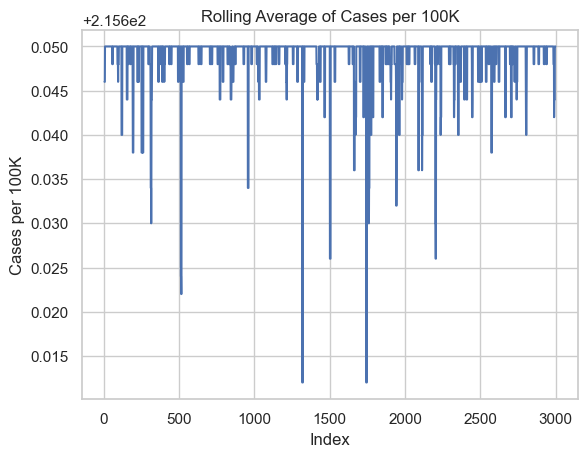

In [44]:
print('Problem 27: Perform a rolling average on `Cases_Per_100K`.')

df['Rolling_Avg'] = df['Cases_Per_100K'].rolling(window=5).mean()
df['Rolling_Avg'].plot(title='Rolling Average of Cases per 100K')
plt.xlabel('Index')
plt.ylabel('Cases per 100K')
plt.grid(True)
plt.show()


In [45]:
print('Problem 28: Perform a hypothesis test to check if `Obesity_Rate` is normally distributed.')
print("Shapiro-Wilk test result:", shapiro(df['Obesity_Rate']))

Problem 28: Perform a hypothesis test to check if `Obesity_Rate` is normally distributed.
Shapiro-Wilk test result: ShapiroResult(statistic=np.float64(0.9556446260066039), pvalue=np.float64(2.7029938746388015e-29))


In [46]:
print('Problem 29: Perform a Mann-Whitney U test to compare `Smoking_Rate` between High and Low HDI categories.')

high_hdi = df[(df['HDI_Category'] == 'H') & (df['Smoking_Rate'].notnull())]['Smoking_Rate']
low_hdi = df[(df['HDI_Category'] == 'Low') & (df['Smoking_Rate'].notnull())]['Smoking_Rate']

# Only perform test if both groups have sufficient size
if len(high_hdi) > 1 and len(low_hdi) > 1:
    from scipy.stats import mannwhitneyu
    result = mannwhitneyu(high_hdi, low_hdi)
    print("Mann-Whitney U test result:", result)
else:
    print("Not enough data in either High or Low HDI group to perform the test.")


Problem 29: Perform a Mann-Whitney U test to compare `Smoking_Rate` between High and Low HDI categories.
Not enough data in either High or Low HDI group to perform the test.


In [47]:
print('Problem 30: Perform a correlation test between `Obesity_Rate` and `Smoking_Rate`.')

corr_result = pearsonr(df['Obesity_Rate'], df['Smoking_Rate'])

print(f"Pearson Correlation Coefficient (r): {corr_result[0]:.3f}")
print(f"P-value: {corr_result[1]:.3f}")

Problem 30: Perform a correlation test between `Obesity_Rate` and `Smoking_Rate`.
Pearson Correlation Coefficient (r): 0.008
P-value: 0.678


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")

print('Problem 31: Impact of Socioeconomic Factors on Breast Cancer Rates')
socioeconomic_correlation = df[['GDP_Per_Capita', 'Healthcare_Expenditure', 'Cases_Per_100K', 'Mortality_Rate']].corr()
display(socioeconomic_correlation)

Problem 31: Impact of Socioeconomic Factors on Breast Cancer Rates


,GDP_Per_Capita,Healthcare_Expenditure,Cases_Per_100K,Mortality_Rate
GDP_Per_Capita,1.000000,-0.008520,0.025960,-0.004437
Healthcare_Expenditure,-0.008520,1.000000,-0.021046,0.002876
Cases_Per_100K,0.025960,-0.021046,1.000000,0.628839
Mortality_Rate,-0.004437,0.002876,0.628839,1.000000


In [49]:
import pandas as pd
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")

print("Problem 32: Urbanization and Breast Cancer Prevalence")
urbanization_correlation = df[['Urbanization_Rate', 'Cases_Per_100K', 'Deaths_Per_100K']].corr()
print(urbanization_correlation)

Problem 32: Urbanization and Breast Cancer Prevalence
                   Urbanization_Rate  Cases_Per_100K  Deaths_Per_100K
Urbanization_Rate              1.000          -0.009           -0.011
Cases_Per_100K                -0.009           1.000            0.715
Deaths_Per_100K               -0.011           0.715            1.000


In [50]:
import pandas as pd
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")

print("Problem 33: Screening Rates and Survival Outcomes ") 
screening_survival_correlation = df[['Screening_Rate', 'Survival_Rate']].corr()
print(screening_survival_correlation)

Problem 33: Screening Rates and Survival Outcomes 
                Screening_Rate  Survival_Rate
Screening_Rate           1.000          0.002
Survival_Rate            0.002          1.000


In [4]:
import pandas as pd
from IPython.display import display
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
print("Problem 34: Effect of Lifestyle Factors on Breast Cancer Risk") 
lifestyle_correlation = df[['Obesity_Rate', 'Smoking_Rate', 'Alcohol_Consumption', 'Physical_Activity_Rate', 'Cases_Per_100K']].corr()
display(lifestyle_correlation)

Problem 34: Effect of Lifestyle Factors on Breast Cancer Risk


,Obesity_Rate,Smoking_Rate,Alcohol_Consumption,Physical_Activity_Rate,Cases_Per_100K
Obesity_Rate,1.000000,0.007591,-0.002582,-0.016235,0.001173
Smoking_Rate,0.007591,1.000000,-0.021227,-0.001198,-0.005941
Alcohol_Consumption,-0.002582,-0.021227,1.000000,0.014271,-0.003741
Physical_Activity_Rate,-0.016235,-0.001198,0.014271,1.000000,-0.014422
Cases_Per_100K,0.001173,-0.005941,-0.003741,-0.014422,1.000000


In [52]:
import pandas as pd
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
print("Problem 35: Healthcare Access and Mortality Rate")
healthcare_mortality_correlation = df[['Access_To_Care', 'Mortality_Rate']].corr()
print(healthcare_mortality_correlation)

Problem 35: Healthcare Access and Mortality Rate
                Access_To_Care  Mortality_Rate
Access_To_Care           1.000          -0.049
Mortality_Rate          -0.049           1.000


In [53]:
import pandas as pd
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
print("Problem 36: Age at Diagnosis and Survival Probability")
age_survival_correlation = df[['Average_Diagnosis_Age', 'Survival_Rate']].corr()
print(age_survival_correlation)

Problem 36: Age at Diagnosis and Survival Probability
                       Average_Diagnosis_Age  Survival_Rate
Average_Diagnosis_Age                  1.000          0.027
Survival_Rate                          0.027          1.000


In [54]:
import pandas as pd
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
print("Problem 37: Regional Disparities in Breast Cancer Cases and Deaths")
regional_cases = df.groupby('Region')[['Breast_Cancer_Cases', 'Breast_Cancer_Deaths']].sum()
print(regional_cases)

Problem 37: Regional Disparities in Breast Cancer Cases and Deaths
               Breast_Cancer_Cases  Breast_Cancer_Deaths
Region                                                  
Africa                    55118132              10256972
Asia                      52952476               9853968
Europe                    54992199              10233549
North America             49719903               9252426
Oceania                   51769587               9633819
South America             52927614               9849342


In [55]:
import pandas as pd
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
print("Problem 38: Influence of Family History and Breastfeeding on Breast Cancer Risk")
family_history_correlation = df[['Family_History_Rate', 'Breastfeeding_Rate', 'Cases_Per_100K']].corr()
print(family_history_correlation)

Problem 38: Influence of Family History and Breastfeeding on Breast Cancer Risk
                     Family_History_Rate  Breastfeeding_Rate  Cases_Per_100K
Family_History_Rate                1.000               0.036          -0.048
Breastfeeding_Rate                 0.036               1.000          -0.014
Cases_Per_100K                    -0.048              -0.014           1.000


In [3]:
import pandas as pd
from IPython.display import display
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
print("Problem 39: Effectiveness of Preventive Measures in Reducing Mortality")
preventive_measures_correlation = df[['Screening_Rate', 'Access_To_Care', 'Physical_Activity_Rate', 'Mortality_Rate']].corr()
display(preventive_measures_correlation)

Problem 39: Effectiveness of Preventive Measures in Reducing Mortality


,Screening_Rate,Access_To_Care,Physical_Activity_Rate,Mortality_Rate
Screening_Rate,1.000000,0.013206,-0.043425,-0.011184
Access_To_Care,0.013206,1.000000,0.044957,-0.048774
Physical_Activity_Rate,-0.043425,0.044957,1.000000,-0.011789
Mortality_Rate,-0.011184,-0.048774,-0.011789,1.000000


In [57]:
import pandas as pd
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
print("Problem 40: Comparative Analysis of High vs. Low HDI Countries")
hdi_comparison = df.groupby('HDI_Category')[['Cases_Per_100K', 'Deaths_Per_100K', 'Survival_Rate']].mean()
print(hdi_comparison)

Problem 40: Comparative Analysis of High vs. Low HDI Countries
              Cases_Per_100K  Deaths_Per_100K  Survival_Rate
HDI_Category                                                
High                 215.648           40.128         75.011
Low                  215.649           40.128         74.600
Medium               215.649           40.128         74.160


In [58]:
import pandas as pd
df = pd.read_csv("Breast_Cancer_Global_Dataset.csv")
print("Problem 41: Population Growth and Breast Cancer Burden")
population_cancer_correlation = df[['Population', 'Breast_Cancer_Cases', 'Breast_Cancer_Deaths']].corr()
print(population_cancer_correlation)


Problem 41: Population Growth and Breast Cancer Burden
                      Population  Breast_Cancer_Cases  Breast_Cancer_Deaths
Population                 1.000                1.000                 1.000
Breast_Cancer_Cases        1.000                1.000                 1.000
Breast_Cancer_Deaths       1.000                1.000                 1.000
